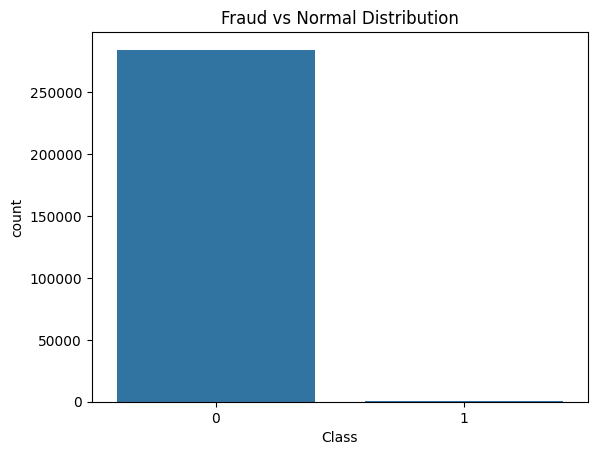

New Shape: (287807, 34)
[[257049  27266]
 [  1977   1515]]
              precision    recall  f1-score   support

           0       0.99      0.90      0.95    284315
           1       0.05      0.43      0.09      3492

    accuracy                           0.90    287807
   macro avg       0.52      0.67      0.52    287807
weighted avg       0.98      0.90      0.94    287807



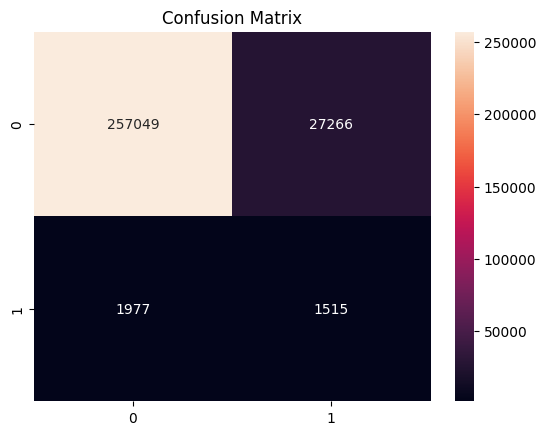

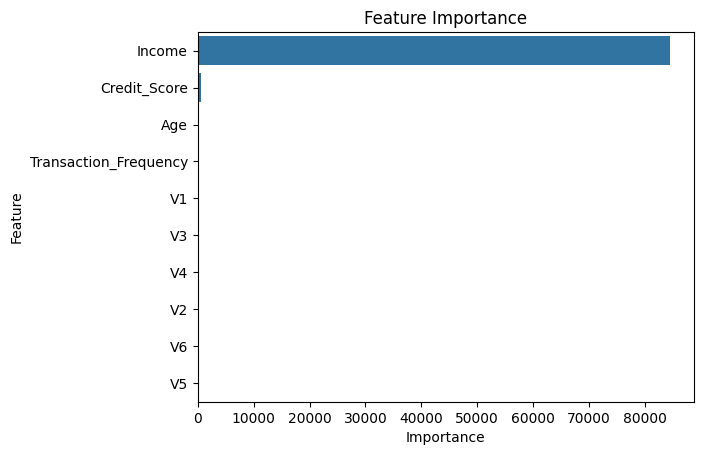

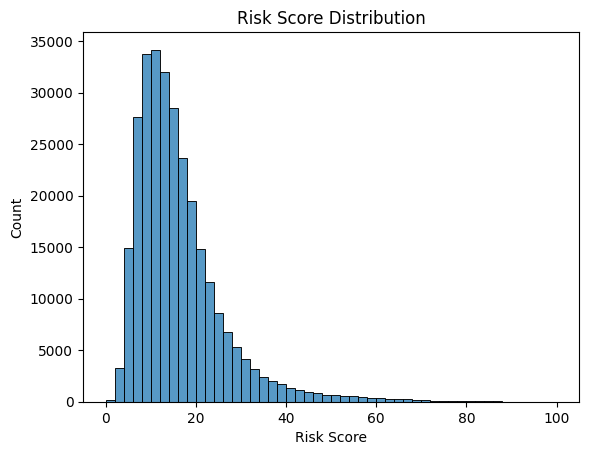


===== FINAL OUTPUT =====
Prediction: 🚨 FRAUD
Risk Score: 100.00%


In [12]:
# 🚨 Advanced Synthetic Identity Fraud Detection System

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv('/content/creditcard.csv')

np.random.seed(42)

df['Age'] = np.random.randint(18, 70, len(df))
df['Income'] = np.random.randint(20000, 150000, len(df))
df['Credit_Score'] = np.random.randint(300, 900, len(df))
df['Transaction_Frequency'] = np.random.randint(1, 50, len(df))

plt.figure()
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Distribution")
plt.show()

scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])

df = df.drop(['Time'], axis=1)

synthetic = df[df['Class'] == 0].sample(3000).copy()

# Inject realistic fraud patterns
synthetic['Amount'] *= np.random.uniform(3, 8, size=len(synthetic))
synthetic['Income'] *= np.random.uniform(0.2, 0.5, size=len(synthetic))
synthetic['Credit_Score'] -= np.random.randint(100, 300, len(synthetic))
synthetic['Transaction_Frequency'] += np.random.randint(20, 100, len(synthetic))

# Noise
for col in synthetic.columns[:-1]:
    synthetic[col] += np.random.normal(0, 0.3, size=len(synthetic))

synthetic['Class'] = 1

df_aug = pd.concat([df, synthetic])

print("New Shape:", df_aug.shape)

X = df_aug.drop('Class', axis=1)
y = df_aug['Class']

model = IsolationForest(contamination=0.1, random_state=42)
model.fit(X)

preds = model.predict(X)
preds = np.where(preds == -1, 1, 0)

print(confusion_matrix(y, preds))
print(classification_report(y, preds))

cm = confusion_matrix(y, preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

importance = np.mean(np.abs(X), axis=0)

imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

plt.figure()
sns.barplot(x='Importance', y='Feature', data=imp_df.head(10))
plt.title("Feature Importance")
plt.show()

scores = model.decision_function(X)

risk = (1 - scores)
risk = (risk - risk.min()) / (risk.max() - risk.min())
risk = risk * 100

df_aug['Risk Score'] = risk

plt.figure()
sns.histplot(df_aug['Risk Score'], bins=50)
plt.title("Risk Score Distribution")
plt.show()

sample = X.sample(1)

prediction = model.predict(sample)
prediction = 1 if prediction[0] == -1 else 0

score = model.decision_function(sample)
risk = max(0, min(100, (1 - score[0]) * 100))

print("\n===== FINAL OUTPUT =====")
print("Prediction:", "🚨 FRAUD" if prediction else "✅ NORMAL")
print(f"Risk Score: {risk:.2f}%")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')